## 1. Importação das bibliotecas

In [1]:
import sys
print(sys.executable)

import pandas as pd
print("Pandas funcionando!")
print(pd.__version__)

RANDOM_STATE = 42

c:\projetos\tech-challenge-fase2-grupo28\.venv\Scripts\python.exe
Pandas funcionando!
2.2.3


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
from pathlib import Path

# Identifica a raiz do projeto (pasta acima de notebooks)
RAIZ_PROJETO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Define a pasta de saída dos gráficos
PASTA_FIGURAS = RAIZ_PROJETO / "results" / "figures"
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)

print("Raiz do projeto:", RAIZ_PROJETO)
print("Pasta dos gráficos:", PASTA_FIGURAS)

Raiz do projeto: c:\projetos\tech-challenge-fase2-grupo28
Pasta dos gráficos: c:\projetos\tech-challenge-fase2-grupo28\results\figures


## 2. CARREGAMENTO DAS BASES

In [4]:
import pandas as pd
from pathlib import Path

# Pasta onde estão os arquivos
pasta_dados = Path("../data/raw")

# Caminho dos arquivos
arquivo_application = pasta_dados / "application_record.csv"
arquivo_credit = pasta_dados / "credit_record.csv"

# Verificar se os arquivos existem
print("Application existe?", arquivo_application.exists())
print("Credit existe?", arquivo_credit.exists())

# Carregar as bases
application = pd.read_csv(arquivo_application)
credit = pd.read_csv(arquivo_credit)

# Verificar o tamanho das bases
print("\nBase APPLICATION:")
print(application.shape)

print("\nBase CREDIT:")
print(credit.shape)

Application existe? True
Credit existe? True



Base APPLICATION:
(438557, 18)

Base CREDIT:
(1048575, 3)


## 3. ANÁLISE E TRATAMENTO DOS DADOS

In [5]:
# Informações da base de aplicações
display(application.head())

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [6]:
# Informações da base de histórico de crédito
display(credit.head())

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [7]:
print("Colunas da APPLICATION:")
print(application.columns.tolist())

print("\nColunas da CREDIT:")
print(credit.columns.tolist())

Colunas da APPLICATION:
['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS']

Colunas da CREDIT:
['ID', 'MONTHS_BALANCE', 'STATUS']


In [8]:
application = pd.read_csv(arquivo_application)
credit = pd.read_csv(arquivo_credit)

In [9]:
print("Application Record:")
print(application.shape)

print("\nCredit Record:")
print(credit.shape)

Application Record:
(438557, 18)

Credit Record:
(1048575, 3)


A base `application_record.csv` contém as características cadastrais e socioeconômicas dos solicitantes de crédito.

In [10]:
application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


A base de histórico de crédito contém registros mensais. Assim, um mesmo cliente pode aparecer em várias linhas, cada uma referente a um período ou status do histórico.

In [11]:
credit.head(20)

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
5,5001712,-1,C
6,5001712,-2,C
7,5001712,-3,C
8,5001712,-4,C
9,5001712,-5,C


In [12]:
application.info()
credit.info()
application.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,438557.0,NaN,NaN,NaN,6022176.269842,571637.023257,5008804.0,5609375.0,6047745.0,6456971.0,7999952.0
CODE_GENDER,438557,2,F,294440,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_CAR,438557,2,N,275459,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_REALTY,438557,2,Y,304074,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CNT_CHILDREN,438557.0,NaN,NaN,NaN,0.42739,0.724882,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,438557.0,NaN,NaN,NaN,187524.28601,110086.853066,26100.0,121500.0,160780.5,225000.0,6750000.0
NAME_INCOME_TYPE,438557,5,Working,226104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_EDUCATION_TYPE,438557,5,Secondary / secondary special,301821,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_FAMILY_STATUS,438557,5,Married,299828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_HOUSING_TYPE,438557,6,House / apartment,393831,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Verificar valores ausentes**

In [13]:
application.isnull().sum().sort_values(ascending=False)
missing = (
    application.isnull()
    .mean()
    .sort_values(ascending=False) * 100
)

missing[missing > 0]

OCCUPATION_TYPE    30.601039
dtype: float64

**Verificação de IDs duplicados e cadastros idênticos**

A qualidade dos dados foi investigada por meio de duas verificações distintas: a identificação de IDs repetidos e a identificação de cadastros idênticos associados a IDs diferentes.

A primeira verificação avalia a unicidade do identificador de cada registro. A ocorrência do mesmo ID em mais de uma linha pode indicar duplicação de registros ou inconsistência na base, devendo ser investigada antes da modelagem.

A segunda verificação compara as informações cadastrais desconsiderando a coluna ID. Dessa forma, é possível identificar registros cujos atributos são idênticos, embora estejam associados a identificadores diferentes. Esse padrão pode representar cadastros duplicados na base e merece atenção, pois registros idênticos ou muito semelhantes podem aparecer simultaneamente nos conjuntos de treinamento e teste, tornando a avaliação do modelo menos representativa de sua capacidade de generalização.

Por esse motivo, as duas verificações são complementares: a primeira examina a unicidade do identificador, enquanto a segunda investiga a repetição do conteúdo cadastral independentemente do identificador.

**Verificação de IDs duplicado**

In [14]:
application["ID"].duplicated().sum()
application[application["ID"].duplicated(keep=False)].head(20)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
421211,7702516,F,N,Y,2,180000.0,Working,Secondary / secondary special,Married,House / apartment,-11753,-1256,1,1,1,0,Sales staff,4.0
421268,7602432,M,N,Y,0,315000.0,Commercial associate,Higher education,Civil marriage,House / apartment,-16627,-1304,1,0,1,0,Drivers,2.0
421349,7602432,F,N,N,0,117000.0,Pensioner,Higher education,Married,House / apartment,-24708,365243,1,0,0,0,NaN,2.0
421464,7836971,M,Y,N,1,157500.0,Working,Secondary / secondary special,Married,House / apartment,-13771,-5520,1,0,0,0,NaN,3.0
421698,7213374,M,Y,N,0,148500.0,Working,Secondary / secondary special,Married,House / apartment,-9950,-961,1,0,1,0,Laborers,2.0
421726,7052783,M,Y,Y,0,157500.0,Working,Higher education,Married,House / apartment,-13428,-2589,1,0,1,0,Laborers,2.0
421907,7023651,M,Y,N,1,157500.0,Commercial associate,Incomplete higher,Married,House / apartment,-10521,-1457,1,0,0,0,Drivers,3.0
422068,7838075,M,N,Y,0,337500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-18198,-1275,1,0,0,1,Drivers,2.0
422077,7636389,M,N,N,0,135000.0,Commercial associate,Higher education,Married,House / apartment,-9624,-666,1,0,1,0,Core staff,2.0
422119,7052812,F,N,Y,0,135000.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15002,-123,1,0,0,0,Accountants,1.0


**Verificação de cadastros idênticos**

In [15]:
# Verificar cadastros idênticos com IDs diferentes

print("Colunas disponíveis:")
print(application.columns.tolist())

# Separar as colunas cadastrais, excluindo o ID
colunas_cadastro = [
    coluna for coluna in application.columns
    if coluna != "ID"
]

# Identificar registros iguais em todas as colunas cadastrais
duplicados_cadastro = application[
    application.duplicated(
        subset=colunas_cadastro,
        keep=False
    )
].sort_values(by=colunas_cadastro)

print(
    "\nQuantidade de registros envolvidos em duplicidade cadastral:",
    len(duplicados_cadastro)
)

if not duplicados_cadastro.empty:
    quantidade_grupos = duplicados_cadastro[
        colunas_cadastro
    ].drop_duplicates().shape[0]

    print(
        "Quantidade de cadastros distintos com duplicidade:",
        quantidade_grupos
    )

    print("\nAmostra de até 10 registros encontrados:")
    print(
        duplicados_cadastro[
            ["ID"] + colunas_cadastro
        ].head(10).to_string(index=False)
    )

    print("\nAmostra de até 10 cadastros com seus números de IDs:")
    ids_por_cadastro = (
        duplicados_cadastro.groupby(
            colunas_cadastro,
            dropna=False
        )["ID"]
        .nunique()
        .reset_index(name="quantidade_ids")
    )

    print(ids_por_cadastro.head(10).to_string(index=False))

    print(
        "\nA análise completa foi mantida em duplicados_cadastro. "
        "Apenas a exibição foi limitada a 10 registros e 10 grupos."
    )
else:
    print(
        "Nenhum cadastro idêntico foi encontrado "
        "considerando todas as colunas, exceto ID."
    )

Colunas disponíveis:
['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS']

Quantidade de registros envolvidos em duplicidade cadastral: 423253
Quantidade de cadastros distintos com duplicidade: 74781

Amostra de até 10 registros encontrados:
     ID CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL NAME_INCOME_TYPE           NAME_EDUCATION_TYPE NAME_FAMILY_STATUS NAME_HOUSING_TYPE  DAYS_BIRTH  DAYS_EMPLOYED  FLAG_MOBIL  FLAG_WORK_PHONE  FLAG_PHONE  FLAG_EMAIL OCCUPATION_TYPE  CNT_FAM_MEMBERS
6093713           F            N               N             0           26100.0        Pensioner Secondary / secondary special            Married House / apartment      -21003         365243           1                0    

In [16]:
# Confirmar cadastros idênticos associados a IDs diferentes

colunas_cadastro = [
    coluna for coluna in application.columns
    if coluna != "ID"
]

duplicados_cadastro = application[
    application.duplicated(
        subset=colunas_cadastro,
        keep=False
    )
]

grupos = duplicados_cadastro.groupby(
    colunas_cadastro,
    dropna=False
)["ID"].agg(["nunique", "size"])

# Selecionar apenas cadastros associados a mais de um ID
grupos_ids_diferentes = grupos[
    grupos["nunique"] > 1
]

print(
    "Quantidade de cadastros idênticos com IDs diferentes:",
    len(grupos_ids_diferentes)
)

print(
    "Total de registros nesses grupos:",
    grupos_ids_diferentes["size"].sum()
)

print("\nExemplos de grupos encontrados:")
print(grupos_ids_diferentes.head(10))

Quantidade de cadastros idênticos com IDs diferentes: 74781
Total de registros nesses grupos: 423253

Exemplos de grupos encontrados:
                                                                                                                                                                                                                                                                      nunique  \
CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY CNT_CHILDREN AMT_INCOME_TOTAL NAME_INCOME_TYPE NAME_EDUCATION_TYPE           NAME_FAMILY_STATUS NAME_HOUSING_TYPE DAYS_BIRTH DAYS_EMPLOYED FLAG_MOBIL FLAG_WORK_PHONE FLAG_PHONE FLAG_EMAIL OCCUPATION_TYPE CNT_FAM_MEMBERS            
F           N            N               0            26100.0          Pensioner        Secondary / secondary special Married            House / apartment -21003      365243       1          0               0          0          NaN             2.0                    2   
                                               

Para construir uma base de modelagem com uma observação por cliente, é necessário resumir o histórico mensal em uma variável-alvo por `ID`.

In [17]:
application = application.drop_duplicates(subset="ID", keep="first")
print(application.shape)
print(application["ID"].nunique())

(438510, 18)
438510


**Análise do histórico de crédito**

In [18]:
credit["STATUS"].value_counts()

STATUS
C    442031
0    383120
X    209230
1     11090
5      1693
2       868
3       320
4       223
Name: count, dtype: int64

In [19]:
credit["STATUS"].value_counts(normalize=True) * 100

STATUS
C    42.155401
0    36.537205
X    19.953747
1     1.057626
5     0.161457
2     0.082779
3     0.030518
4     0.021267
Name: proportion, dtype: float64

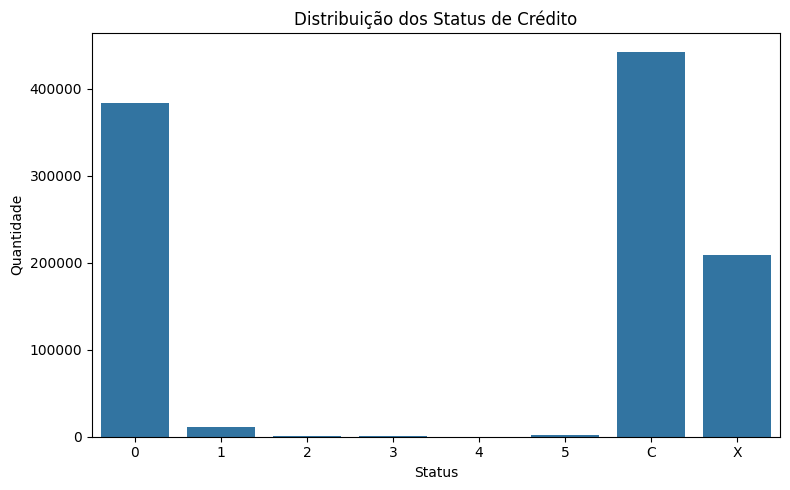

In [20]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=credit,
    x="STATUS",
    order=sorted(credit["STATUS"].unique())
)

plt.title("Distribuição dos Status de Crédito")
plt.xlabel("Status")
plt.ylabel("Quantidade")

plt.tight_layout()
plt.savefig(
    PASTA_FIGURAS / "distribuicao_status_credito.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

O gráfico apresenta a distribuição dos registros segundo o status de crédito. Observa-se maior frequência dos status `C` e `0`, enquanto os demais status aparecem com menor frequência. Como essas categorias representam situações distintas do histórico, é importante definir explicitamente a regra usada para construir a variável-alvo antes do treinamento dos modelos.

**Construção de variável alvo**

Na regra adotada neste projeto, os status de `1` a `5` são considerados indicativos de ocorrência de atraso ou inadimplência. Essa definição operacional será utilizada para construir a variável-alvo; ela não deve ser interpretada como uma classificação definitiva do risco futuro do cliente.

In [21]:
bad_status=["1", "2", "3", "4", "5"]

In [22]:
credit["BAD_STATUS"] = credit["STATUS"].isin(bad_status).astype(int)

In [23]:
credit.head()

,ID,MONTHS_BALANCE,STATUS,BAD_STATUS
0,5001711,0,X,0
1,5001711,-1,0,0
2,5001711,-2,0,0
3,5001711,-3,0,0
4,5001712,0,C,0


**Conversão do histórico mensal em classificação por cliente**

Um cliente será classificado como mau pagador (`TARGET = 1`) se apresentar pelo menos um registro com status entre `1` e `5` no histórico analisado. Caso contrário, será classificado como bom pagador (`TARGET = 0`), conforme a regra definida para este estudo.

In [24]:
target = (
    credit
    .groupby("ID")["BAD_STATUS"]
    .max()
    .reset_index()
)

In [25]:
target = target.rename(columns={
    "BAD_STATUS": "TARGET"
})

`TARGET = 0` → bom pagador, segundo a regra adotada.

`TARGET = 1` → mau pagador, segundo a regra adotada.

In [26]:
target.head()

,ID,TARGET
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0


**Distribuição da variável-alvo**

In [27]:
target["TARGET"].value_counts()

TARGET
0    40635
1     5350
Name: count, dtype: int64

In [28]:
target["TARGET"].value_counts(normalize=True) * 100

TARGET
0    88.365771
1    11.634229
Name: proportion, dtype: float64

A variável-alvo apresenta **desbalanceamento de classes**: há muito mais registros classificados como bons pagadores do que como maus pagadores. Nesse cenário, a acurácia isolada pode ser enganosa, pois um modelo pode acertar a maioria da classe predominante e ainda deixar de identificar muitos casos positivos.

Por isso, a avaliação considera precisão (*precision*), sensibilidade (*recall*), F1, ROC-AUC, PR-AUC e acurácia balanceada (*balanced accuracy*).

**Junção das bases**

A base de aplicação será combinada com a variável-alvo construída a partir do histórico de crédito. O conjunto resultante será utilizado nas etapas de análise e modelagem.

In [29]:
df = application.merge(
    target,
    on="ID",
    how="inner"
)

In [30]:
print("Linhas em application:", len(application))
print("IDs únicos em application:", application["ID"].nunique())

print("\nLinhas em target:", len(target))
print("IDs únicos em target:", target["ID"].nunique())

print("\nLinhas em df após o merge:", len(df))
print("IDs únicos em df:", df["ID"].nunique())

print("\nIDs duplicados em application:",
      application["ID"].duplicated().sum())

print("IDs duplicados em target:",
      target["ID"].duplicated().sum())

print("IDs duplicados em df:",
      df["ID"].duplicated().sum())

Linhas em application: 438510
IDs únicos em application: 438510

Linhas em target: 45985
IDs únicos em target: 45985

Linhas em df após o merge: 36457
IDs únicos em df: 36457

IDs duplicados em application: 0
IDs duplicados em target: 0
IDs duplicados em df: 0


Os testes indicam que não há IDs duplicados nas bases verificadas. Essa checagem é diferente da investigação de cadastros idênticos associados a IDs distintos, realizada posteriormente.

In [31]:
ids_application = set(application["ID"])
ids_target = set(target["ID"])
ids_df = set(df["ID"])

print("IDs de application que não estão em target:",
      len(ids_application - ids_target))

print("IDs de target que não estão em application:",
      len(ids_target - ids_application))

print("IDs de target que entraram em df:",
      len(ids_df))

print("Total de IDs em target:",
      len(ids_target))

print("Percentual de target mantido no df:",
      round(len(ids_df) / len(ids_target) * 100, 2), "%")

IDs de application que não estão em target: 402053
IDs de target que não estão em application: 9528
IDs de target que entraram em df: 36457
Total de IDs em target: 45985
Percentual de target mantido no df: 79.28 %


9.528 IDs presentes na tabela `target` não possuem correspondência na base `application` e, por isso, não entram na base final obtida pela junção.

In [32]:
print("Distribuição de TARGET em target:")
print(target["TARGET"].value_counts())
print("\nProporção em target:")
print(target["TARGET"].value_counts(normalize=True).round(3))

print("\nDistribuição de TARGET em df:")
print(df["TARGET"].value_counts())
print("\nProporção em df:")
print(df["TARGET"].value_counts(normalize=True).round(3))

Distribuição de TARGET em target:
TARGET
0    40635
1     5350
Name: count, dtype: int64

Proporção em target:
TARGET
0    0.884
1    0.116
Name: proportion, dtype: float64

Distribuição de TARGET em df:
TARGET
0    32166
1     4291
Name: count, dtype: int64

Proporção em df:
TARGET
0    0.882
1    0.118
Name: proportion, dtype: float64


A proporção de bons e maus pagadores mudou pouco após a junção das bases. Isso sugere que, entre os clientes que permaneceram no conjunto combinado, a distribuição da variável-alvo foi preservada de forma aproximada. Ainda assim, muitos registros não possuem correspondência entre as duas bases e ficam fora da análise conjunta.

In [33]:
print("Quantidade de IDs distintos em credit:",
      credit["ID"].nunique())

print("Quantidade de IDs distintos em target:",
      target["ID"].nunique())

print("Quantidade de IDs distintos em application:",
      application["ID"].nunique())

print("\nPrimeiros IDs de credit:")
print(credit["ID"].head().tolist())

print("\nPrimeiros IDs de application:")
print(application["ID"].head().tolist())

Quantidade de IDs distintos em credit: 45985
Quantidade de IDs distintos em target: 45985
Quantidade de IDs distintos em application: 438510

Primeiros IDs de credit:
[5001711, 5001711, 5001711, 5001711, 5001712]

Primeiros IDs de application:
[5008804, 5008805, 5008806, 5008808, 5008809]


In [34]:
print(df.shape)
df.head()

(36457, 19)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0


****Verificação da variável-alvo - Target**

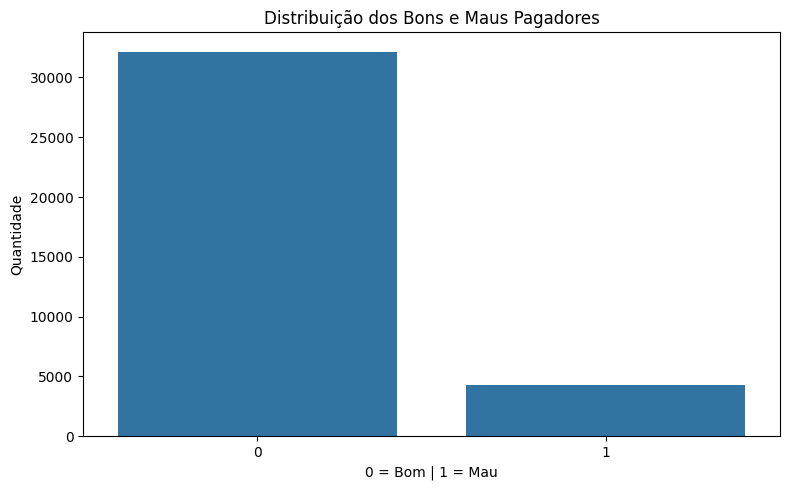

In [35]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="TARGET")

plt.title("Distribuição dos Bons e Maus Pagadores")
plt.xlabel("0 = Bom | 1 = Mau")
plt.ylabel("Quantidade")

plt.tight_layout()
plt.savefig(
    PASTA_FIGURAS / "distribuicao_bons_maus_pagadores.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

O gráfico apresenta a distribuição dos clientes entre as classes definidas para o modelo: bons pagadores (`TARGET = 0`) e maus pagadores (`TARGET = 1`).

Há predominância de bons pagadores, com aproximadamente 32 mil registros, enquanto a classe de maus pagadores possui menos de 5 mil registros. Esse desbalanceamento deve ser considerado na seleção das métricas e na interpretação dos resultados.

**Análise exploratória — idade**

In [36]:
df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365.25

Na base original, a variável `DAYS_BIRTH` representa a idade em dias com sinal negativo. Para facilitar a interpretação, ela é convertida em anos e apresentada como `AGE_YEARS`.

In [37]:
df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365.25

In [38]:
df["AGE_YEARS"].describe()

count    36457.000000
mean        43.737641
std         11.500479
min         20.503765
25%         34.119097
50%         42.609172
75%         53.218344
max         68.862423
Name: AGE_YEARS, dtype: float64

O gráfico permite comparar a distribuição da idade entre os grupos definidos por `TARGET`.

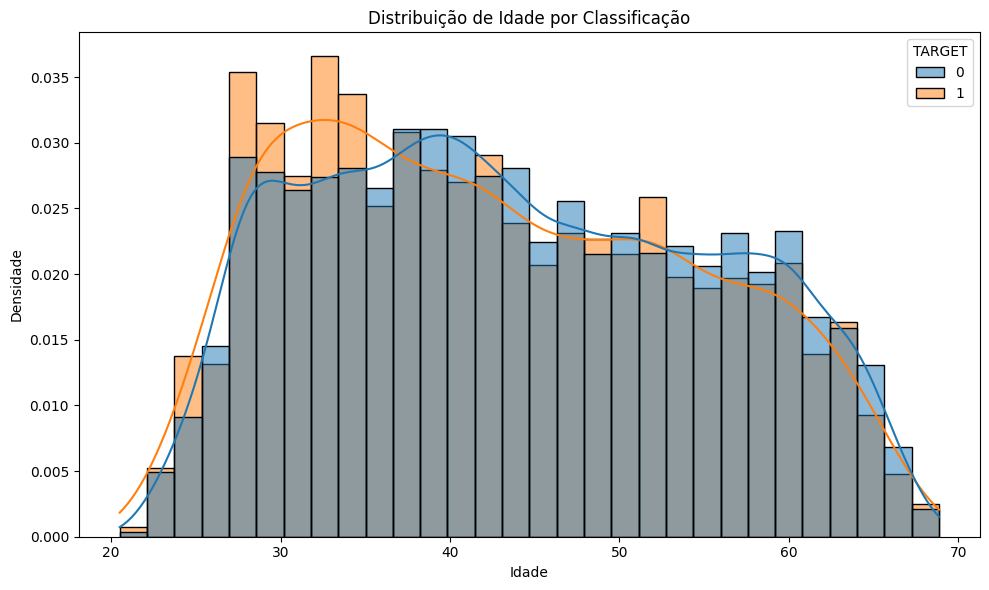

In [39]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="AGE_YEARS",
    hue="TARGET",
    bins=30,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("Distribuição de Idade por Classificação")
plt.xlabel("Idade")
plt.ylabel("Densidade")

plt.tight_layout()
plt.savefig(
    PASTA_FIGURAS / "distribuicao_idade_classificacao.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

As distribuições de idade apresentam diferenças entre as classes, mas há sobreposição entre os grupos. A análise exploratória, portanto, sugere uma possível associação entre idade e a classificação definida no projeto, sem demonstrar que a idade cause inadimplência ou que seja suficiente para classificar corretamente um cliente. Qualquer uso dessa variável em decisões de crédito exigiria validação adicional e análise de adequação e equidade.  

**Análise da renda**

In [40]:
df["AMT_INCOME_TOTAL"].describe()

count    3.645700e+04
mean     1.866857e+05
std      1.017892e+05
min      2.700000e+04
25%      1.215000e+05
50%      1.575000e+05
75%      2.250000e+05
max      1.575000e+06
Name: AMT_INCOME_TOTAL, dtype: float64

A renda costuma apresentar uma distribuição assimétrica, com concentração de observações em faixas menores e uma cauda de valores elevados.

In [41]:
df["INCOME_LOG"] = np.log1p(df["AMT_INCOME_TOTAL"])

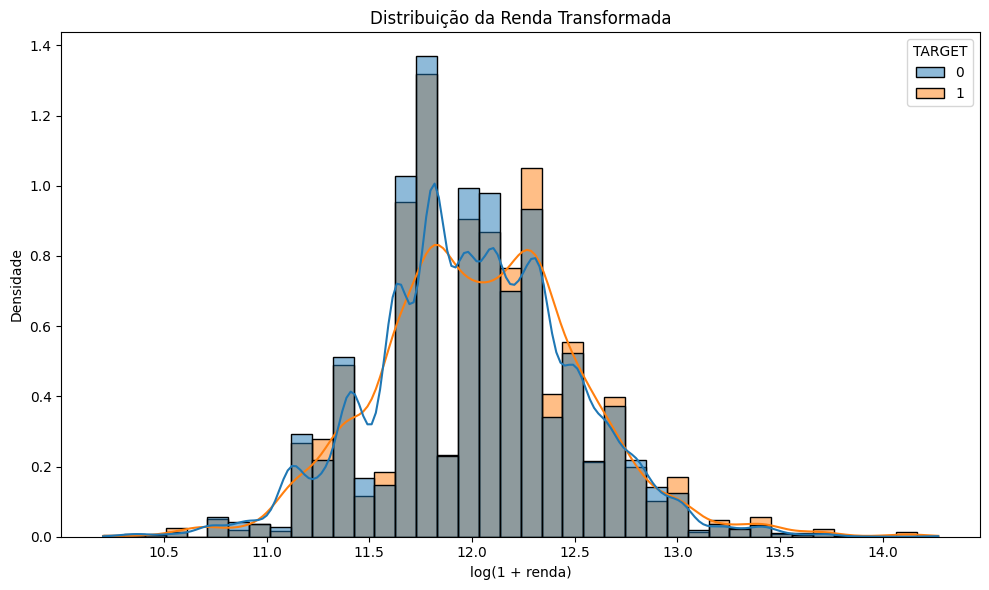

In [42]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="INCOME_LOG",
    hue="TARGET",
    bins=40,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("Distribuição da Renda Transformada")
plt.xlabel("log(1 + renda)")
plt.ylabel("Densidade")

plt.tight_layout()
plt.savefig(
    PASTA_FIGURAS / "distribuicao_renda_transformada.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

O gráfico apresenta a distribuição de `INCOME_LOG`, a transformação logarítmica da renda, para os grupos `TARGET = 0` e `TARGET = 1`. A transformação reduz a influência de valores muito elevados e facilita a visualização da distribuição.

As curvas apresentam sobreposição considerável, indicando que a renda transformada, isoladamente, não separa claramente os grupos nesta análise exploratória. Isso não significa que a renda seja irrelevante em qualquer modelo; sua contribuição deve ser avaliada em conjunto com as demais variáveis e com as métricas obtidas na validação.

**Renda em relação ao número de pessoas da família**

In [43]:
df["INCOME_PER_FAMILY"] = (
    df["AMT_INCOME_TOTAL"] /
    df["CNT_FAM_MEMBERS"].replace(0, np.nan)
)

**Tempo de emprego**

A variável original `DAYS_EMPLOYED` apresenta valores negativos por representar o tempo em relação a uma referência temporal. Além disso, o valor `365243` é uma codificação especial utilizada na base e foi tratado como ausência de informação, conforme a regra de pré-processamento adotada. A variável derivada `EMPLOYED_YEARS` facilita a interpretação do tempo de emprego.

In [44]:
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(
    365243,
    np.nan
)

In [45]:
df["EMPLOYED_YEARS"] = -df["DAYS_EMPLOYED"] / 365.25

**Análise de relações entre variáveis categóricas**

**Tipo de renda**

Como `TARGET` assume os valores 0 e 1, a média de `TARGET` em cada categoria corresponde à proporção de registros classificados como maus pagadores naquela categoria.

In [46]:
income_type_target = (
    df.groupby("NAME_INCOME_TYPE")["TARGET"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

income_type_target

,mean,count
NAME_INCOME_TYPE,,
State servant,0.128978,2985
Commercial associate,0.127208,8490
Working,0.115894,18819
Pensioner,0.104681,6152
Student,0.090909,11


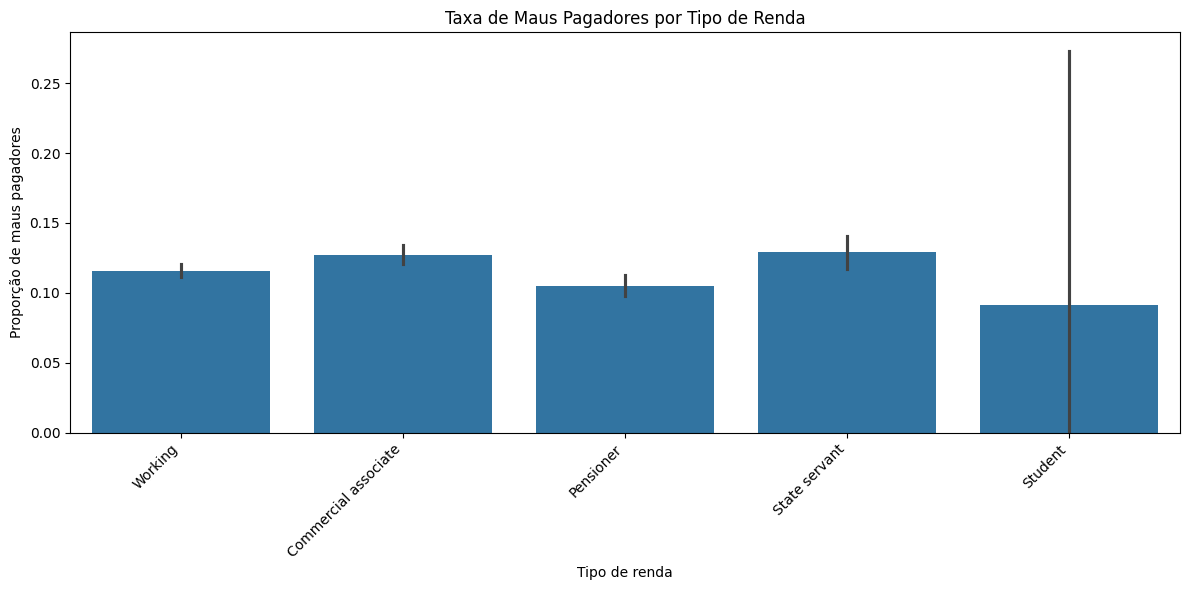

In [47]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x="NAME_INCOME_TYPE",
    y="TARGET"
)

plt.xticks(rotation=45, ha="right")
plt.title("Taxa de Maus Pagadores por Tipo de Renda")
plt.xlabel("Tipo de renda")
plt.ylabel("Proporção de maus pagadores")

plt.tight_layout()
plt.savefig(
    PASTA_FIGURAS / "taxa_maus_pagadores_tipo_renda.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

O gráfico compara a proporção de registros classificados como maus pagadores entre as categorias de `NAME_INCOME_TYPE`. As diferenças observadas devem ser interpretadas com cautela, especialmente nas categorias com poucas observações, nas quais a estimativa pode ser menos estável.

A variável representa o tipo de renda, não necessariamente a profissão do cliente. Como as taxas das categorias podem se sobrepor, o tipo de renda isoladamente não deve ser usado para concluir que um cliente apresenta maior ou menor risco. Sua contribuição precisa ser avaliada em conjunto com as demais variáveis.

*Observação: as diferenças representam associações observadas nos dados e não demonstram que o tipo de renda cause inadimplência.*

**Escolaridade**

In [48]:
education_target = (
    df.groupby("NAME_EDUCATION_TYPE")["TARGET"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

education_target

,mean,count
NAME_EDUCATION_TYPE,,
Academic degree,0.218750,32
Incomplete higher,0.146809,1410
Secondary / secondary special,0.116640,24777
Higher education,0.116383,9864
Lower secondary,0.104278,374


## 4. MODELAGEM

As seguintes variáveis não serão utilizadas diretamente como preditoras:

- `ID`: identificador do cliente, sem significado preditivo apropriado para este objetivo.
- `TARGET`: variável que se deseja prever.
- `DAYS_BIRTH`: substituída pela variável derivada `AGE_YEARS`.
- `DAYS_EMPLOYED`: substituída pela variável derivada `EMPLOYED_YEARS`.
- `AMT_INCOME_TOTAL`: substituída por `INCOME_LOG`, transformação logarítmica da renda.

Essas decisões buscam evitar o uso de identificadores e de variáveis redundantes com as transformações criadas.

In [49]:
X = df.drop(
    columns=[
        "ID",
        "TARGET",
        "DAYS_BIRTH",
        "DAYS_EMPLOYED",
        "AMT_INCOME_TOTAL"
    ]
)

y = df["TARGET"]

In [50]:
print(X.shape)
print(y.shape)

(36457, 18)
(36457,)


**Separação das variáveis numéricas e categóricas**

In [51]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Variáveis numéricas:")
print(numeric_features)

print("\nVariáveis categóricas:")
print(categorical_features)

Variáveis numéricas:
['CNT_CHILDREN', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'AGE_YEARS', 'INCOME_LOG', 'INCOME_PER_FAMILY', 'EMPLOYED_YEARS']

Variáveis categóricas:
['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']


**Separação entre treino e teste**

A divisão foi planejada para utilizar aproximadamente 80% dos registros no treinamento e 20% no teste. Como foi aplicado o método `StratifiedGroupKFold`, a proporção efetiva pode não ser exatamente 80%/20%.

A estratificação busca preservar a distribuição da variável-alvo, enquanto o agrupamento mantém registros cadastrais idênticos no mesmo conjunto, reduzindo o risco de vazamento entre treino e teste.

In [52]:
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold

# Conferir se cada ID identifica um único cadastro na base original
if not application["ID"].is_unique:
    raise ValueError(
        "A base application contém IDs repetidos. "
        "Precisamos investigar esses IDs antes de continuar."
    )

# Criar um grupo para cada combinação de dados cadastrais,
# desconsiderando a coluna ID
colunas_cadastro = [
    coluna for coluna in application.columns
    if coluna != "ID"
]

application_com_grupo = application.copy()

application_com_grupo["grupo_duplicidade"] = (
    application_com_grupo
    .groupby(colunas_cadastro, dropna=False)
    .ngroup()
)

# Associar cada ID ao respectivo grupo cadastral
grupo_por_id = application_com_grupo.set_index("ID")[
    "grupo_duplicidade"
]

# Alinhar os grupos com as linhas utilizadas na modelagem
grupos = df["ID"].map(grupo_por_id)

if grupos.isna().any():
    raise ValueError(
        "Existem IDs de df que não foram encontrados em application."
    )

print("Total de linhas na modelagem:", len(df))
print("Total de grupos cadastrais:", grupos.nunique())
print("Grupos com mais de um registro:",
      grupos.value_counts().gt(1).sum())

Total de linhas na modelagem: 36457
Total de grupos cadastrais: 9728
Grupos com mais de um registro: 6591


Na base utilizada na modelagem, existem registros com características cadastrais idênticas associados a IDs diferentes. Por isso, os grupos de duplicidade foram considerados na divisão entre treinamento e teste.

In [53]:
# Divisão estratificada e agrupada: aproximadamente 80% / 20%

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, test_idx = next(
    cv.split(X, y, groups=grupos)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# Confirmar que nenhum grupo aparece nos dois conjuntos
grupos_treino = set(grupos.iloc[train_idx])
grupos_teste = set(grupos.iloc[test_idx])

sobreposicao = grupos_treino.intersection(grupos_teste)

print("Registros de treino:", len(X_train))
print("Registros de teste:", len(X_test))
print("Proporção de teste:",
      round(len(X_test) / len(X), 3))
print("Grupos compartilhados entre treino e teste:",
      len(sobreposicao))

print("\nProporção de TARGET no conjunto completo:")
print(y.value_counts(normalize=True).round(3))

print("\nProporção de TARGET no treino:")
print(y_train.value_counts(normalize=True).round(3))

print("\nProporção de TARGET no teste:")
print(y_test.value_counts(normalize=True).round(3))

assert len(sobreposicao) == 0, (
    "Erro: há grupos cadastrais compartilhados entre treino e teste."
)

Registros de treino: 29077
Registros de teste: 7380
Proporção de teste: 0.202
Grupos compartilhados entre treino e teste: 0

Proporção de TARGET no conjunto completo:
TARGET
0    0.882
1    0.118
Name: proportion, dtype: float64

Proporção de TARGET no treino:
TARGET
0    0.883
1    0.117
Name: proportion, dtype: float64

Proporção de TARGET no teste:
TARGET
0    0.881
1    0.119
Name: proportion, dtype: float64


A divisão agrupada não apresentou grupos cadastrais compartilhados entre treino e teste. A proporção da classe positiva permaneceu próxima da observada na base completa, embora o método de divisão possa produzir conjuntos com tamanhos ligeiramente diferentes da proporção nominal de 80%/20%.

In [54]:
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

print("\nDistribuição no treino:")
print(y_train.value_counts(normalize=True))

print("\nDistribuição no teste:")
print(y_test.value_counts(normalize=True))

Treino: (29077, 18)
Teste: (7380, 18)

Distribuição no treino:
TARGET
0    0.882656
1    0.117344
Name: proportion, dtype: float64

Distribuição no teste:
TARGET
0    0.880894
1    0.119106
Name: proportion, dtype: float64


**Pré-processamento**

O pré-processamento considera dois tipos de variáveis.

**Variáveis numéricas**
- Preenchimento de valores ausentes pela mediana.
- Padronização das variáveis.

**Variáveis categóricas**
- Preenchimento de valores ausentes pela categoria mais frequente.
- Aplicação de *One-Hot Encoding* para representar as categorias numericamente.

As transformações são organizadas em uma pipeline para que o pré-processamento seja ajustado no conjunto de treinamento e aplicado de forma consistente aos dados de teste e a novos registros.

In [55]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

In [56]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

**Primeiro modelo: Regressão Logística**

A Regressão Logística foi incluída como modelo de referência para a classificação binária. A configuração utiliza `class_weight="balanced"` para considerar o desbalanceamento entre as classes, além do pré-processamento definido na pipeline.

In [57]:
class_weight="balanced"

In [58]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [59]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessor criado com sucesso!")

Preprocessor criado com sucesso!


**Treinamento da Regressão Logística**

In [60]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42,
                class_weight="balanced",
                C=0.5
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CNT_CHILDREN', 'FLAG_MOBIL',
                                                   'FLAG_WORK_PHONE',
                                                   'FLAG_PHONE', 'FLAG_EMAIL',
                                                   'CNT_FAM_MEMBERS',
                                                   'AGE_YEARS', 'INCOME_LOG',
                                                   'INCOME_PER_FAMILY',
                                                   'EMPLOYED_YEARS']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE'])])),
                ('classifier',
                 LogisticRegression(C=0.5, class_weight='balanced',
                                    max_iter=2000, random_state=42))])

In [61]:
import joblib

# Define a pasta onde o modelo será salvo
PASTA_MODELOS = RAIZ_PROJETO / "results" / "models"
PASTA_MODELOS.mkdir(parents=True, exist_ok=True)

# Salva a pipeline treinada
caminho_modelo = PASTA_MODELOS / "modelo_logistic_regression.joblib"

joblib.dump(logistic_model, caminho_modelo)

print("Modelo salvo em:", caminho_modelo)
print("Arquivo existe:", caminho_modelo.exists())

Modelo salvo em: c:\projetos\tech-challenge-fase2-grupo28\results\models\modelo_logistic_regression.joblib
Arquivo existe: True


In [62]:
import joblib

# Carrega o modelo salvo
modelo_carregado = joblib.load(caminho_modelo)

# Confirma que o modelo foi carregado
print("Modelo carregado com sucesso!")
print(modelo_carregado)

Modelo carregado com sucesso!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CNT_CHILDREN', 'FLAG_MOBIL',
                                                   'FLAG_WORK_PHONE',
                                                   'FLAG_PHONE', 'FLAG_EMAIL',
                                                   'CNT_FAM_MEMBERS',
                                                   'AGE_YEARS', 'INCOME_LOG',
                                                   'INCOME_PER_FAMILY',
                                                   'EMPLOYED_YEARS']),
              

In [63]:
previsoes_teste = modelo_carregado.predict(X_test)

print("Quantidade de previsões:", len(previsoes_teste))
print("Primeiras 10 previsões:", previsoes_teste[:10])

Quantidade de previsões: 7380
Primeiras 10 previsões: [1 1 1 1 1 1 1 1 1 1]


**Modelo 2: Random Forest**

In [64]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=400,
                min_samples_leaf=5,
                max_features="sqrt",
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

**Treinamento do Random Forest**

In [65]:
rf_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CNT_CHILDREN', 'FLAG_MOBIL',
                                                   'FLAG_WORK_PHONE',
                                                   'FLAG_PHONE', 'FLAG_EMAIL',
                                                   'CNT_FAM_MEMBERS',
                                                   'AGE_YEARS', 'INCOME_LOG',
                                                   'INCOME_PER_FAMILY',
                                                   'EMPLOYED_YEARS']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        min_samples_leaf=5, n_estimators=400,
                                        n_jobs=-1, random_state=42))])

**Modelo 3: Extra Trees**

In [66]:
extra_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            ExtraTreesClassifier(
                n_estimators=400,
                min_samples_leaf=3,
                max_features="sqrt",
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

**Treinamento do Extra Trees**

In [67]:
extra_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CNT_CHILDREN', 'FLAG_MOBIL',
                                                   'FLAG_WORK_PHONE',
                                                   'FLAG_PHONE', 'FLAG_EMAIL',
                                                   'CNT_FAM_MEMBERS',
                                                   'AGE_YEARS', 'INCOME_LOG',
                                                   'INCOME_PER_FAMILY',
                                                   'EMPLOYED_YEARS']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE'])])),
                ('classifier',
                 ExtraTreesClassifier(class_weight='balanced',
                                      min_samples_leaf=3, n_estimators=400,
                                      n_jobs=-1, random_state=42))])

**Função de avaliação dos modelos**

In [68]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_prob
        ),
        "PR-AUC": average_precision_score(
            y_test,
            y_prob
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_test,
            y_pred
        )
    }

    return metrics

**Comparação dos três modelos**

In [69]:
results = []

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "Extra Trees": extra_model
}

for name, model in models.items():

    metrics = evaluate_model(
        model,
        X_test,
        y_test
    )

    metrics["Model"] = name

    results.append(metrics)

results_df = pd.DataFrame(results)

results_df = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC",
        "Balanced Accuracy"
    ]
]

display(results_df.round(6))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Balanced Accuracy
0,Logistic Regression,0.555149,0.117684,0.420933,0.183942,0.512367,0.126150,0.497115
1,Random Forest,0.861111,0.155660,0.037543,0.060495,0.512384,0.126746,0.505004
2,Extra Trees,0.813279,0.134700,0.104664,0.117798,0.507376,0.124848,0.506878


Os valores da tabela estão arredondados para facilitar a leitura.

- **Precisão (*precision*):** a Regressão Logística apresenta precisão de aproximadamente 11,8%. Entre os casos previstos como maus pagadores, essa é a proporção que pertence de fato à classe positiva.
- **Recall:** a Regressão Logística identifica aproximadamente 42,1% dos maus pagadores do conjunto de teste, o maior valor entre os três modelos.
- **F1:** a Regressão Logística apresenta o maior F1 (aproximadamente 0,184), embora o valor continue baixo.
- **ROC-AUC:** os três modelos apresentam valores próximos de 0,5, indicando capacidade limitada de ordenar os clientes entre as duas classes.
- **PR-AUC:** os valores ficam próximos da prevalência da classe positiva no teste, de aproximadamente 11,9%, sugerindo ganho limitado em relação a uma referência simples.
- **Acurácia (*accuracy*):** o Random Forest apresenta a maior acurácia (aproximadamente 86,1%), mas seu recall é de apenas 3,8%. Portanto, deixa de identificar a grande maioria dos maus pagadores.

Considerando o objetivo de identificar a classe de risco, a Regressão Logística é a candidata mais adequada entre as três na configuração e no limiar avaliados, por apresentar o maior recall e F1. Entretanto, os resultados globais ainda são insuficientes para justificar o uso do modelo em decisões reais de crédito sem melhorias e validação adicional.

Foi realizada uma análise de duplicidade na base cadastral, desconsiderando a coluna identificadora (`ID`) e comparando as demais variáveis. A investigação identificou 74.780 grupos de cadastros com atributos idênticos associados a IDs diferentes na base original.

Para reduzir o risco de vazamento de dados entre os conjuntos de treinamento e teste, foi utilizada uma divisão estratificada e agrupada com `StratifiedGroupKFold`. Os grupos cadastrais foram mantidos integralmente em um único conjunto, sem sobreposição entre treino e teste.

A divisão resultou em 29.077 registros para treinamento e 7.380 para teste. A proporção da classe positiva (`TARGET = 1`) permaneceu próxima de 11,8% nos dois conjuntos. Após essa alteração, os modelos foram treinados e avaliados novamente.

A Regressão Logística apresentou o maior recall e o maior F1 entre os modelos avaliados. O Random Forest apresentou maior acurácia, mas recall muito baixo para a classe positiva. Como os valores de ROC-AUC ficaram próximos de 0,5 e os valores de PR-AUC foram apenas ligeiramente superiores à prevalência da classe positiva, os resultados indicam capacidade discriminativa limitada. São necessárias novas investigações antes de qualquer aplicação operacional.

In [70]:
from sklearn.metrics import confusion_matrix, classification_report

for nome, modelo in models.items():
    y_pred = modelo.predict(X_test)

    print("\n" + "=" * 50)
    print(f"Modelo: {nome}")
    print("=" * 50)

    print("\nMatriz de confusão:")
    print(confusion_matrix(y_test, y_pred))

    print("\nRelatório de classificação:")
    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0,
            digits=3
        )
    )


Modelo: Logistic Regression

Matriz de confusão:
[[3727 2774]
 [ 509  370]]

Relatório de classificação:
              precision    recall  f1-score   support

           0      0.880     0.573     0.694      6501
           1      0.118     0.421     0.184       879

    accuracy                          0.555      7380
   macro avg      0.499     0.497     0.439      7380
weighted avg      0.789     0.555     0.633      7380


Modelo: Random Forest

Matriz de confusão:
[[6322  179]
 [ 846   33]]

Relatório de classificação:
              precision    recall  f1-score   support

           0      0.882     0.972     0.925      6501
           1      0.156     0.038     0.060       879

    accuracy                          0.861      7380
   macro avg      0.519     0.505     0.493      7380
weighted avg      0.795     0.861     0.822      7380


Modelo: Extra Trees

Matriz de confusão:
[[5910  591]
 [ 787   92]]

Relatório de classificação:
              precision    recall  f1-scor

In [71]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

for nome, modelo in models.items():
    y_pred = modelo.predict(X_test)
    matriz = confusion_matrix(y_test, y_pred)

    print(f"\nModelo: {nome}")
    print("Matriz de confusão:")
    print(matriz)
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.3f}")
    print(f"Recall:    {recall_score(y_test, y_pred, zero_division=0):.3f}")
    print(f"F1:        {f1_score(y_test, y_pred, zero_division=0):.3f}")


Modelo: Logistic Regression
Matriz de confusão:
[[3727 2774]
 [ 509  370]]
Accuracy:  0.555
Precision: 0.118
Recall:    0.421
F1:        0.184

Modelo: Random Forest
Matriz de confusão:
[[6322  179]
 [ 846   33]]
Accuracy:  0.861
Precision: 0.156
Recall:    0.038
F1:        0.060

Modelo: Extra Trees
Matriz de confusão:
[[5910  591]
 [ 787   92]]
Accuracy:  0.813
Precision: 0.135
Recall:    0.105
F1:        0.118


**Matriz de confusão — Regressão Logística**

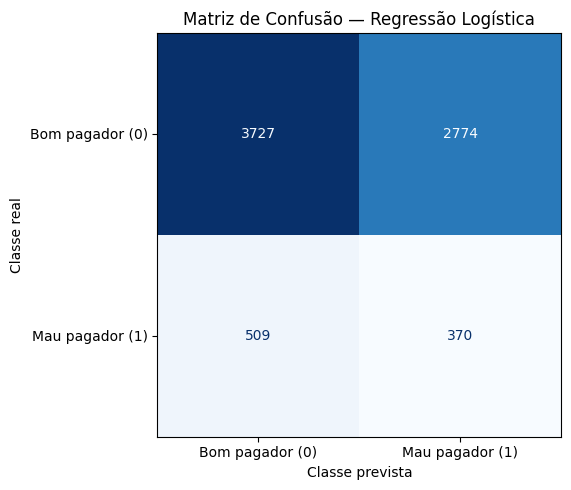

Matriz de confusão — Regressão Logística:
[[3727 2774]
 [ 509  370]]


In [72]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Previsões da Regressão Logística no conjunto de teste
y_pred_log = logistic_model.predict(X_test)

# Matriz de confusão
cm_log = confusion_matrix(
    y_test,
    y_pred_log,
    labels=[0, 1]
)

# Gráfico
fig, ax = plt.subplots(figsize=(7, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log,
    display_labels=["Bom pagador (0)", "Mau pagador (1)"]
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

ax.set_title("Matriz de Confusão — Regressão Logística")
ax.set_xlabel("Classe prevista")
ax.set_ylabel("Classe real")

plt.tight_layout()
fig.savefig(
    PASTA_FIGURAS / "matriz_confusao_logistica.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Matriz de confusão — Regressão Logística:")
print(cm_log)

A matriz de confusão avalia a classificação da Regressão Logística entre bons e maus pagadores. Considerando a classe 1 como indicativa de mau pagador, o modelo identificou corretamente 370 dos 879 casos dessa classe, correspondendo a um recall de aproximadamente 42,1%. Por outro lado, classificou incorretamente 509 maus pagadores como bons pagadores.

Além disso, 2.774 bons pagadores foram classificados incorretamente como maus pagadores, gerando falsos positivos. Portanto, o modelo apresenta erros nas duas classes. O resultado evidencia o compromisso entre identificar potenciais inadimplentes e evitar classificações incorretas, reforçando a necessidade de avaliar diferentes métricas e os custos associados a cada tipo de erro.

**Matriz de confusão — Random Forest**

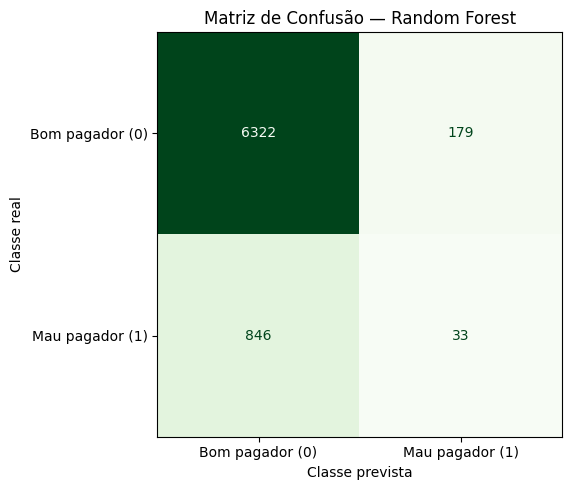

Matriz de confusão — Random Forest:
[[6322  179]
 [ 846   33]]


In [73]:
# Previsões da Random Forest no mesmo conjunto de teste
y_pred_rf = rf_model.predict(X_test)

# Matriz de confusão
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=[0, 1]
)

# Gráfico
fig, ax = plt.subplots(figsize=(7, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Bom pagador (0)", "Mau pagador (1)"]
)

disp.plot(
    ax=ax,
    cmap="Greens",
    values_format="d",
    colorbar=False
)

ax.set_title("Matriz de Confusão — Random Forest")
ax.set_xlabel("Classe prevista")
ax.set_ylabel("Classe real")

plt.tight_layout()
fig.savefig(
    PASTA_FIGURAS / "matriz_confusao_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Matriz de confusão — Random Forest:")
print(cm_rf)

A matriz de confusão do Random Forest apresenta 6.322 acertos na classe dos bons pagadores. Entretanto, o modelo identificou corretamente apenas 33 dos 879 maus pagadores presentes no conjunto de teste, correspondendo a um recall de aproximadamente 3,8% para a classe positiva.

Além disso, 846 maus pagadores foram classificados incorretamente como bons pagadores. Embora o modelo apresente elevada acurácia global, esse indicador isoladamente não representa adequadamente seu desempenho em uma base desbalanceada. Por isso, é importante considerar recall, precisão, F1 e PR-AUC na avaliação da identificação do risco de crédito.

**Comparação das matrizes de confusão**

Na configuração e no limiar avaliados, a Regressão Logística identificou uma parcela maior dos maus pagadores do que o Random Forest: seu recall foi de aproximadamente 42,1%, contra 3,8% do Random Forest. Em contrapartida, a Regressão Logística também produziu muitos falsos positivos. Assim, ela é a candidata mais promissora entre as avaliadas quando a prioridade é recuperar casos da classe positiva, mas seu desempenho ainda precisa ser aprimorado.

**Curva ROC**

A Curva ROC avalia um classificador binário em diferentes limiares, relacionando a taxa de verdadeiros positivos (*True Positive Rate*, TPR) à taxa de falsos positivos (*False Positive Rate*, FPR). A área sob a curva (ROC-AUC) resume a capacidade de discriminação: valores próximos de 0,5 indicam desempenho semelhante ao de uma ordenação aleatória.

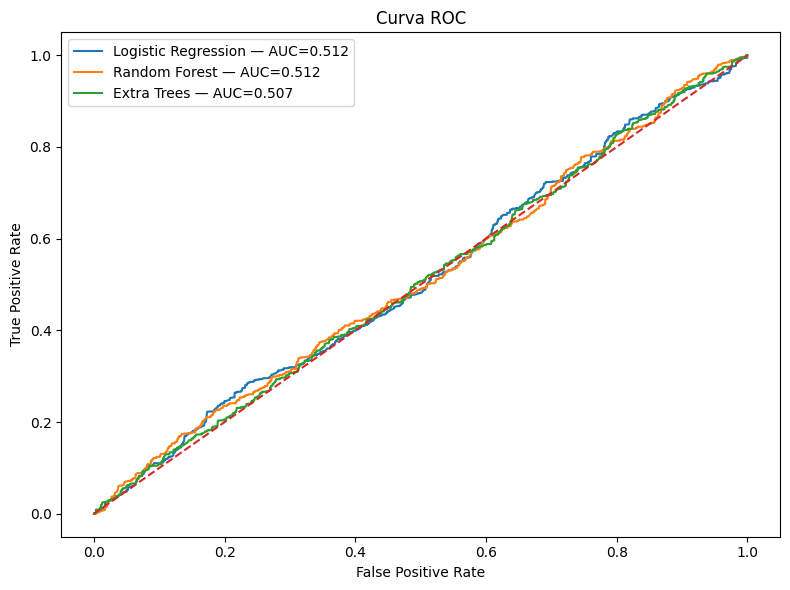

In [74]:
plt.figure(figsize=(8, 6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} — AUC={auc:.3f}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()

plt.tight_layout()
plt.savefig(
    PASTA_FIGURAS / "curva_roc.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

A Curva ROC compara a capacidade dos três modelos de distinguir bons e maus pagadores em diferentes limiares. Na avaliação realizada, a Regressão Logística apresentou ROC-AUC de aproximadamente **0,512**, o Random Forest **0,512** e o Extra Trees **0,507**.

Os três resultados estão próximos de 0,5, indicando capacidade de discriminação limitada. As pequenas diferenças numéricas não sustentam a conclusão de que um dos modelos apresente desempenho discriminativo forte. Considerando também o maior recall e F1 observados para a Regressão Logística, ela será tratada como a candidata selecionada para as próximas etapas deste projeto, sem que isso represente uma recomendação para uso operacional. São necessárias melhorias e validação adicional.

**Curva Precision-Recall**

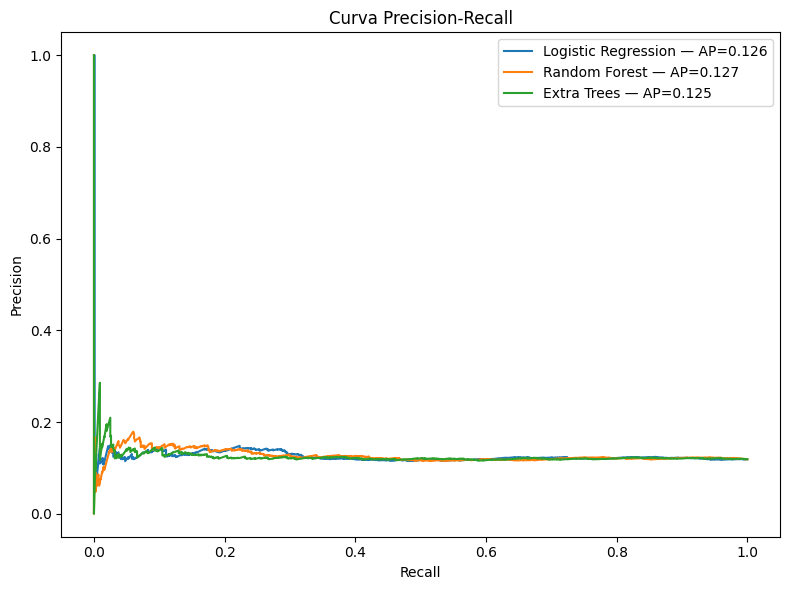

In [75]:
plt.figure(figsize=(8, 6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    ap = average_precision_score(
        y_test,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} — AP={ap:.3f}"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.legend()

plt.tight_layout()
plt.savefig(
    PASTA_FIGURAS / "curva_precision_recall.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

A Curva Precision-Recall relaciona precisão e recall em diferentes limiares e é especialmente útil em problemas com classes desbalanceadas. A Precisão Média (*Average Precision*, AP) foi de aproximadamente **0,126 para a Regressão Logística**, **0,127 para o Random Forest** e **0,125 para o Extra Trees**.

Os valores são próximos entre si e da prevalência da classe positiva no conjunto de teste (aproximadamente 11,9%). Isso indica ganho limitado na identificação da classe minoritária. Embora o Random Forest tenha obtido AP ligeiramente maior, a diferença é pequena; além disso, seu recall no limiar padrão é muito baixo. A Regressão Logística será considerada a candidata selecionada com base no compromisso observado entre recall e F1, mas seu desempenho precisa ser aprimorado antes de qualquer uso operacional.

**Importância das variáveis por permutação**

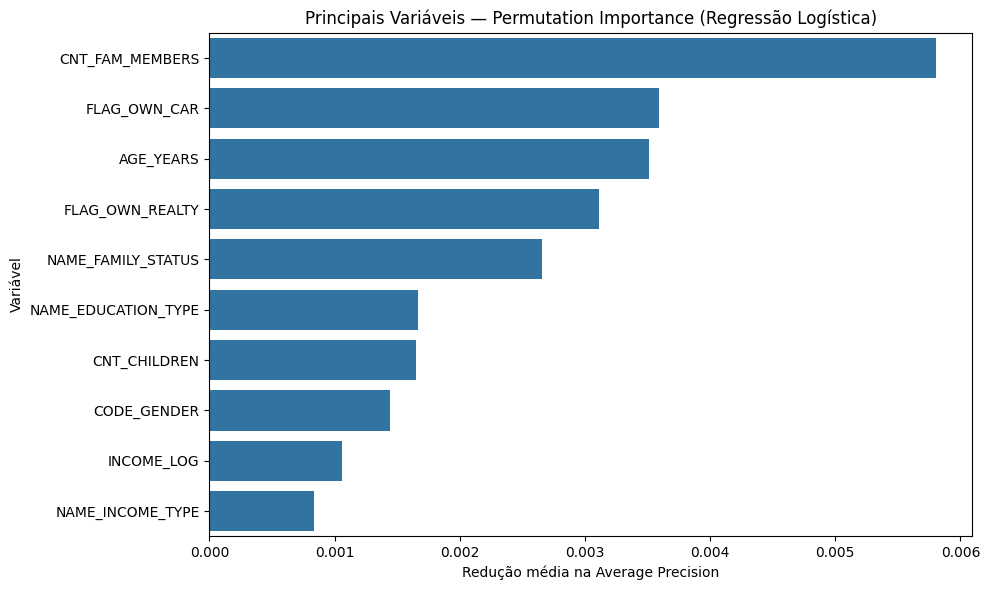

,Feature,Importance
13,CNT_FAM_MEMBERS,0.005804
1,FLAG_OWN_CAR,0.003593
14,AGE_YEARS,0.003512
2,FLAG_OWN_REALTY,0.003110
6,NAME_FAMILY_STATUS,0.002656
5,NAME_EDUCATION_TYPE,0.001666
3,CNT_CHILDREN,0.001653
0,CODE_GENDER,0.001441
15,INCOME_LOG,0.001056
4,NAME_INCOME_TYPE,0.000836


In [76]:
from sklearn.inspection import permutation_importance
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calcula a importância por permutação da Regressão Logística
perm_importance_log = permutation_importance(
    logistic_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=5,
    random_state=42,
    n_jobs=1
)

# Organiza os resultados
importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance_log.importances_mean
}).sort_values(
    by="Importance",
    ascending=False
)

# Seleciona as dez variáveis mais importantes
top_features = importance_df.head(10)

# Gera o gráfico
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Principais Variáveis — Permutation Importance "
    "(Regressão Logística)"
)
plt.xlabel("Redução média na Average Precision")
plt.ylabel("Variável")

plt.tight_layout()
plt.savefig(
    PASTA_FIGURAS / "permutation_importance_logistica.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Exporta os resultados completos
importance_df.to_csv(
    RAIZ_PROJETO / "results" / "metrics" /
    "importancia_variaveis_logistica.csv",
    index=False
)

display(importance_df.head(10).round(6))




In [77]:
importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance_log.importances_mean
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

display(importance_df.head(15).round(6))

,Feature,Importance
13,CNT_FAM_MEMBERS,0.005804
1,FLAG_OWN_CAR,0.003593
14,AGE_YEARS,0.003512
2,FLAG_OWN_REALTY,0.003110
6,NAME_FAMILY_STATUS,0.002656
5,NAME_EDUCATION_TYPE,0.001666
3,CNT_CHILDREN,0.001653
0,CODE_GENDER,0.001441
15,INCOME_LOG,0.001056
4,NAME_INCOME_TYPE,0.000836


A importância por permutação foi utilizada para avaliar a contribuição relativa das variáveis para o desempenho da Regressão Logística, considerando a Average Precision como métrica de avaliação. O método consiste em embaralhar os valores de uma variável por vez e observar a alteração no desempenho do modelo.

Variáveis cuja permutação provoca maior redução na métrica tendem a contribuir mais para o desempenho preditivo do modelo avaliado. Valores próximos de zero indicam contribuição limitada segundo esse procedimento, enquanto valores negativos podem indicar que a permutação melhorou o resultado observado.

A análise representa uma associação com o desempenho preditivo, e não uma relação causal. Além disso, a importância por permutação pode ser influenciada por correlações entre variáveis. Os resultados devem ser interpretados considerando também as limitações de discriminação identificadas na avaliação geral do modelo.

**Gráfico das principais variáveis**

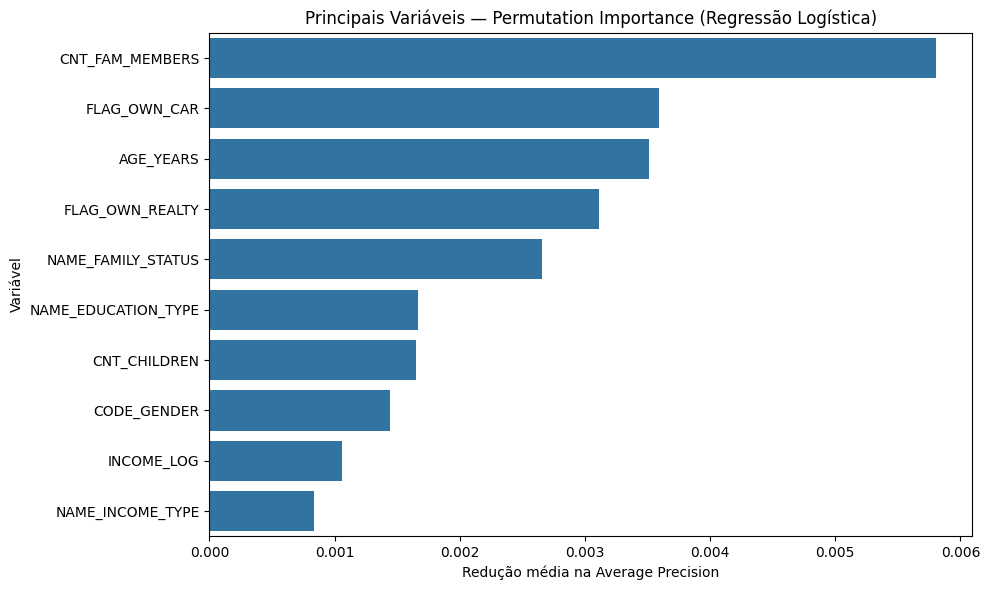

In [78]:

# Seleciona as dez variáveis mais importantes
top_features = importance_df.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Principais Variáveis — Permutation Importance "
    "(Regressão Logística)"
)

plt.xlabel("Redução média na Average Precision")
plt.ylabel("Variável")

plt.tight_layout()
plt.savefig(
    PASTA_FIGURAS / "permutation_importance_logistica.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


O gráfico apresenta as dez variáveis com maior importância média por permutação para a Regressão Logística, considerando a redução média na métrica de desempenho utilizada na avaliação. O procedimento consiste em embaralhar os valores de cada variável individualmente e observar quanto o desempenho do modelo se altera.

Entre as variáveis apresentadas, OCCUPATION_TYPE obteve a maior importância, seguida por EMPLOYED_YEARS, NAME_EDUCATION_TYPE e FLAG_OWN_CAR. Também se destacaram FLAG_PHONE, FLAG_WORK_PHONE, AGE_YEARS e CNT_CHILDREN. Já INCOME_LOG e FLAG_OWN_REALTY apresentaram valores menores entre as dez variáveis exibidas.

Esses resultados sugerem que as informações relacionadas à ocupação, ao tempo de emprego, à escolaridade e à posse de veículo contribuíram relativamente mais para o desempenho preditivo observado nessa análise. Entretanto, a importância por permutação não demonstra causalidade nem indica, por si só, que uma característica aumenta ou reduz o risco de inadimplência.

Além disso, as diferenças de importância são relativamente pequenas, e variáveis correlacionadas podem compartilhar informações. Portanto, os resultados devem ser interpretados com cautela, especialmente considerando que o desempenho geral dos modelos apresentou capacidade limitada de discriminação entre bons e maus pagadores.

# 5. Exportação dos resultados

In [79]:
from pathlib import Path

# Pasta onde serão salvos os resultados processados
pasta_processed = Path("../data/processed")

# Cria a pasta caso ela não exista
pasta_processed.mkdir(parents=True, exist_ok=True)

# Salvar métricas dos modelos
arquivo_metricas = pasta_processed / "metricas_modelos.csv"
results_df.to_csv(arquivo_metricas, index=False)

# Salvar importância das variáveis
arquivo_importancia = pasta_processed / "importancia_variaveis.csv"
importance_df.to_csv(arquivo_importancia, index=False)

print("Arquivos salvos com sucesso!")
print(f"Métricas: {arquivo_metricas.resolve()}")
print(f"Importância das variáveis: {arquivo_importancia.resolve()}")


Arquivos salvos com sucesso!
Métricas: C:\projetos\tech-challenge-fase2-grupo28\data\processed\metricas_modelos.csv
Importância das variáveis: C:\projetos\tech-challenge-fase2-grupo28\data\processed\importancia_variaveis.csv


In [80]:
from pathlib import Path

predictions = pd.DataFrame({
    "y_real": y_test.values,
    "y_pred": y_pred_rf,
    "probabilidade_mau_pagador": rf_model.predict_proba(X_test)[:, 1]
})

# Pasta de destino
pasta_processed = Path("../data/processed")
pasta_processed.mkdir(parents=True, exist_ok=True)

# Salvar diretamente em data/processed
arquivo_predicoes = pasta_processed / "predicoes_random_forest.csv"

predictions.to_csv(
    arquivo_predicoes,
    index=False
)

print("Predições salvas em:")
print(arquivo_predicoes.resolve())

Predições salvas em:
C:\projetos\tech-challenge-fase2-grupo28\data\processed\predicoes_random_forest.csv


## Síntese do desenvolvimento

1. A base de aplicação fornece as características cadastrais dos clientes.
2. A base de crédito fornece o histórico mensal de comportamento de pagamento.
3. Foi construída uma variável-alvo a partir dos status históricos de crédito.
4. Foram classificados como maus pagadores os clientes que apresentaram pelo menos um status entre 1 e 5, conforme a regra adotada no projeto.
5. As bases foram cruzadas para relacionar o histórico de crédito às características cadastrais.
6. Foram realizadas análises de qualidade dos dados, incluindo a verificação de IDs repetidos e de cadastros idênticos associados a IDs diferentes.
7. Foram aplicadas transformações e criadas variáveis derivadas, incluindo idade, tempo de emprego e renda logarítmica.
8. A divisão entre treinamento e teste considerou os grupos de cadastros idênticos, buscando evitar a sobreposição desses grupos entre os conjuntos.
9. Foi desenvolvido um pipeline de pré-processamento para variáveis numéricas e categóricas.
10. Foram treinados e comparados três algoritmos: Regressão Logística, Random Forest e Extra Trees.
11. A Regressão Logística apresentou o maior recall (0,421) e o maior F1 (0,184), enquanto o Random Forest apresentou a maior acurácia (0,861). A acurácia elevada do Random Forest, entretanto, veio acompanhada de recall muito baixo (0,038) para a classe de maus pagadores.
12. Os valores de ROC-AUC, próximos de 0,5, e os resultados de PR-AUC indicaram limitações importantes na capacidade de discriminação dos modelos.
13. Foi realizada uma análise exploratória de importância por permutação para investigar a contribuição relativa das variáveis na Regressão Logística.

Conclui-se que os modelos avaliados ainda não apresentam desempenho suficiente para sustentar, isoladamente, decisões reais de concessão de crédito. A Regressão Logística mostrou maior capacidade de recuperar a classe de maus pagadores no limiar utilizado, mas também produziu um número elevado de falsos positivos. São recomendadas investigações adicionais, validações e análises de custos antes de uma eventual aplicação operacional.